## Fashion MNIST Classification with 3DCNN

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

2021-09-22 03:19:04.132896: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0


## Utilities

In [2]:
def sample_images(images, row_count, column_count):
    fig, axs = plt.subplots(row_count, column_count, figsize=(10,10))
    for i in range(row_count):
        for j in range(column_count):
            axs[i,j].imshow(images[i * column_count + j])
            axs[i,j].axis('off')
    plt.show()

## Import and preprcess dataset

In [3]:
train = pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_train.csv")
test = pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_test.csv")
train_labels = train.pop("label")
test_labels = test.pop("label")
train_images = np.array(train).reshape((-1, 28, 28, 1, 1)) / 255.0
test_images = np.array(test).reshape((-1, 28, 28, 1, 1)) / 255.0

In [4]:
batch_size = 100

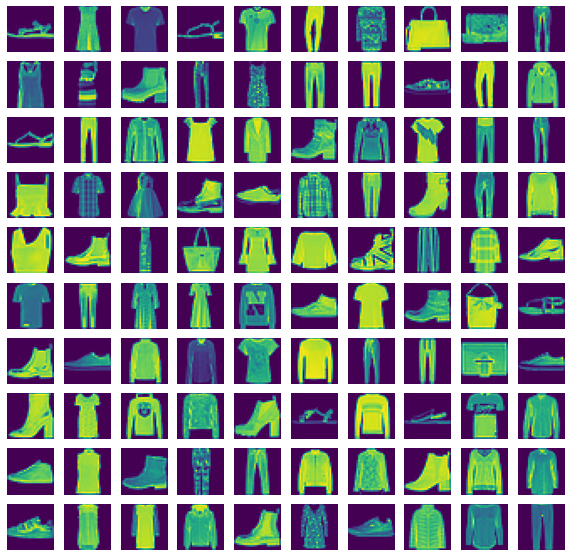

In [5]:
indices = np.random.choice(train_images.shape[0], 100)
sample_images(train_images[indices].squeeze(), 10, 10)

## Model Development

In [6]:
tf.keras.backend.clear_session()
model = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1, 1)),
        layers.Conv3D(32, kernel_size=(3, 3, 1), padding="same", activation="relu"),
        layers.MaxPooling3D(pool_size=(2, 2, 1)),
        layers.Conv3D(64, kernel_size=(3, 3, 1), padding="same", activation="relu"),
        layers.MaxPooling3D(pool_size=(2, 2, 1)),
        layers.Conv3D(128, kernel_size=(3, 3, 1), padding="same", activation="relu"),
        layers.MaxPooling3D(pool_size=(2, 2, 1)),
        layers.GlobalAveragePooling3D(),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

2021-09-22 03:19:22.420171: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2021-09-22 03:19:22.423841: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcuda.so.1
2021-09-22 03:19:22.468935: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:941] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-09-22 03:19:22.470010: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1720] Found device 0 with properties: 
pciBusID: 0000:00:04.0 name: Tesla P100-PCIE-16GB computeCapability: 6.0
coreClock: 1.3285GHz coreCount: 56 deviceMemorySize: 15.90GiB deviceMemoryBandwidth: 681.88GiB/s
2021-09-22 03:19:22.470098: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.11.0
2021-09-22 03:19:22.516527: I tensorflow/stream_executor/platform/def

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv3d (Conv3D)              (None, 28, 28, 1, 32)     320       
_________________________________________________________________
max_pooling3d (MaxPooling3D) (None, 14, 14, 1, 32)     0         
_________________________________________________________________
conv3d_1 (Conv3D)            (None, 14, 14, 1, 64)     18496     
_________________________________________________________________
max_pooling3d_1 (MaxPooling3 (None, 7, 7, 1, 64)       0         
_________________________________________________________________
conv3d_2 (Conv3D)            (None, 7, 7, 1, 128)      73856     
_________________________________________________________________
max_pooling3d_2 (MaxPooling3 (None, 3, 3, 1, 128)      0         
_________________________________________________________________
global_average_pooling3d (Gl (None, 128)               0

## Training

In [7]:
history = model.fit(train_images, train_labels, epochs=30, batch_size=batch_size, validation_data=(test_images, test_labels))

2021-09-22 03:19:25.150641: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2021-09-22 03:19:25.162710: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2199995000 Hz


Epoch 1/30


2021-09-22 03:19:25.774756: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.11
2021-09-22 03:19:26.688126: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublasLt.so.11
2021-09-22 03:19:26.706629: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.8


600/600 [==============================] - 12s 8ms/step - loss: 1.0774 - accuracy: 0.6120 - val_loss: 0.4922 - val_accuracy: 0.8252
Epoch 2/30
600/600 [==============================] - 4s 7ms/step - loss: 0.4802 - accuracy: 0.8271 - val_loss: 0.4192 - val_accuracy: 0.8486
Epoch 3/30
600/600 [==============================] - 4s 7ms/step - loss: 0.4028 - accuracy: 0.8563 - val_loss: 0.3635 - val_accuracy: 0.8718
Epoch 4/30
600/600 [==============================] - 4s 6ms/step - loss: 0.3704 - accuracy: 0.8678 - val_loss: 0.3244 - val_accuracy: 0.8826
Epoch 5/30
600/600 [==============================] - 4s 7ms/step - loss: 0.3341 - accuracy: 0.8798 - val_loss: 0.3263 - val_accuracy: 0.8812
Epoch 6/30
600/600 [==============================] - 4s 7ms/step - loss: 0.3190 - accuracy: 0.8855 - val_loss: 0.2893 - val_accuracy: 0.8982
Epoch 7/30
600/600 [==============================] - 4s 6ms/step - loss: 0.3002 - accuracy: 0.8942 - val_loss: 0.3129 - val_accuracy: 0.8870
Epoch 8/30
600/6

<AxesSubplot:>

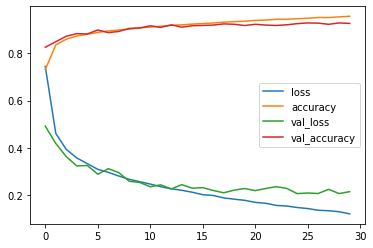

In [8]:
pd.DataFrame(history.history).plot()